In [1]:
# 安装 Gymnasium 环境
!pip -q install gymnasium[classic-control]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import random
import pickle
import json
import os

from scipy import stats

# 固定随机种子，保证实验可复现
MAIN_SEED = 42
np.random.seed(MAIN_SEED)
random.seed(MAIN_SEED)

# 创建实验环境
ENV_NAME = "CartPole-v1"
env = gym.make(ENV_NAME)

obs, info = env.reset(seed=MAIN_SEED)

# 获取状态维度和动作数量
OBS_DIM = env.observation_space.shape[0]
N_ACTIONS = env.action_space.n

# WANN 实验参数
config = {
    "env_name": ENV_NAME,
    "main_seed": MAIN_SEED,
    "seeds": [42, 123],

    # 固定计算预算
    "population_size": 40,
    "generations": 60,
    "eval_episodes": 3,
    "test_episodes": 100,

    # WANN 共享权重集合
    "shared_weights": [-2.0, -1.0, -0.5, 0.5, 1.0, 2.0],

    # 网络结构限制
    "input_dim": OBS_DIM,
    "output_dim": N_ACTIONS,
    "max_hidden_nodes": 12,
    "initial_hidden_nodes": 2,

    # 变异参数
    "add_node_prob": 0.10,
    "add_connection_prob": 0.25,
    "remove_connection_prob": 0.10,
    "activation_mutation_prob": 0.20,

    # 选择参数
    "elite_count": 4,
    "tournament_size": 3
}

# 简单测试环境是否正常
action = env.action_space.sample()
next_obs, reward, terminated, truncated, info = env.step(action)

print("Environment created.")
print("Environment name:", ENV_NAME)
print("Observation dimension:", OBS_DIM)
print("Number of actions:", N_ACTIONS)
print("Initial observation:", obs)
print("Sample action:", action)
print("Next observation:", next_obs)
print("Reward:", reward)
print("Done:", terminated or truncated)
print("Config created.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 54.8 MB/s eta 0:00:00
Environment created.
Environment name: CartPole-v1
Observation dimension: 4
Number of actions: 2
Initial observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Sample action: 1
Next observation: [ 0.02727336  0.18847767  0.03625453 -0.26141977]
Reward: 1.0
Done: False
Config created.


In [2]:
# 激活函数集合
def activation_function(x, name):
    if name == "tanh":
        return np.tanh(x)
    elif name == "relu":
        return np.maximum(0, x)
    elif name == "sigmoid":
        return 1 / (1 + np.exp(-np.clip(x, -50, 50)))
    elif name == "sin":
        return np.sin(x)
    elif name == "linear":
        return x
    else:
        return x


ACTIVATIONS = ["tanh", "relu", "sigmoid", "sin", "linear"]


class WANNIndividual:
    def __init__(self, input_dim, output_dim, max_hidden_nodes=12):
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.max_hidden_nodes = max_hidden_nodes

        # 节点编号
        self.input_nodes = list(range(input_dim))
        self.output_nodes = list(range(input_dim, input_dim + output_dim))
        self.hidden_nodes = []
        self.next_node_id = input_dim + output_dim

        # 连接格式: (from_node, to_node)
        self.connections = []

        # 每个节点的激活函数
        self.activations = {}
        for node in self.output_nodes:
            self.activations[node] = "linear"

    def copy(self):
        # 手动复制个体，避免直接引用同一个对象
        new_ind = WANNIndividual(
            self.input_dim,
            self.output_dim,
            self.max_hidden_nodes
        )
        new_ind.input_nodes = self.input_nodes.copy()
        new_ind.output_nodes = self.output_nodes.copy()
        new_ind.hidden_nodes = self.hidden_nodes.copy()
        new_ind.next_node_id = self.next_node_id
        new_ind.connections = self.connections.copy()
        new_ind.activations = self.activations.copy()
        return new_ind

    def add_hidden_node(self):
        # 添加隐藏节点
        if len(self.hidden_nodes) >= self.max_hidden_nodes:
            return

        node_id = self.next_node_id
        self.next_node_id += 1
        self.hidden_nodes.append(node_id)
        self.activations[node_id] = random.choice(ACTIVATIONS)

    def add_random_connection(self):
        # 添加一条新的前向连接，避免形成循环
        all_nodes = self.input_nodes + self.hidden_nodes + self.output_nodes

        possible_sources = self.input_nodes + self.hidden_nodes
        possible_targets = self.hidden_nodes + self.output_nodes

        for _ in range(30):
            src = random.choice(possible_sources)
            dst = random.choice(possible_targets)

            # 避免自连接
            if src == dst:
                continue

            # 用节点编号限制方向，减少循环风险
            if src > dst:
                continue

            connection = (src, dst)
            if connection not in self.connections:
                self.connections.append(connection)
                return

    def remove_random_connection(self):
        # 随机删除连接
        if len(self.connections) > 0:
            idx = random.randrange(len(self.connections))
            self.connections.pop(idx)

    def mutate_activation(self):
        # 随机改变一个隐藏节点的激活函数
        if len(self.hidden_nodes) == 0:
            return

        node = random.choice(self.hidden_nodes)
        self.activations[node] = random.choice(ACTIVATIONS)

    def initialize_simple_network(self, initial_hidden_nodes=2):
        # 初始化一个简单网络结构
        for _ in range(initial_hidden_nodes):
            self.add_hidden_node()

        # 输入到隐藏层
        for inp in self.input_nodes:
            for hid in self.hidden_nodes:
                self.connections.append((inp, hid))

        # 隐藏层到输出层
        for hid in self.hidden_nodes:
            for out in self.output_nodes:
                self.connections.append((hid, out))

        # 如果没有隐藏节点，直接输入到输出
        if len(self.hidden_nodes) == 0:
            for inp in self.input_nodes:
                for out in self.output_nodes:
                    self.connections.append((inp, out))

    def forward(self, obs, shared_weight):
        # 前向传播，所有连接使用同一个 shared_weight
        values = {}

        # 输入节点赋值
        for i, node in enumerate(self.input_nodes):
            values[node] = obs[i]

        # 其他节点初始值为 0
        for node in self.hidden_nodes + self.output_nodes:
            values[node] = 0.0

        # 按目标节点顺序计算，近似前馈网络
        sorted_connections = sorted(self.connections, key=lambda x: x[1])

        for src, dst in sorted_connections:
            src_value = values.get(src, 0.0)
            values[dst] = values.get(dst, 0.0) + shared_weight * src_value

        # 对隐藏层和输出层应用激活函数
        for node in sorted(self.hidden_nodes + self.output_nodes):
            act_name = self.activations.get(node, "linear")
            values[node] = activation_function(values[node], act_name)

        # 输出动作分数
        outputs = np.array([values[node] for node in self.output_nodes])
        return outputs

    def act(self, obs, shared_weight):
        # 选择输出分数最大的动作
        outputs = self.forward(obs, shared_weight)
        return int(np.argmax(outputs))

    def complexity(self):
        # 统计网络复杂度
        return {
            "hidden_nodes": len(self.hidden_nodes),
            "connections": len(self.connections),
            "parameters": len(self.connections)
        }


# 创建并测试一个 WANN 个体
test_ind = WANNIndividual(
    input_dim=OBS_DIM,
    output_dim=N_ACTIONS,
    max_hidden_nodes=config["max_hidden_nodes"]
)

test_ind.initialize_simple_network(
    initial_hidden_nodes=config["initial_hidden_nodes"]
)

obs, info = env.reset(seed=MAIN_SEED)
outputs = test_ind.forward(obs, shared_weight=1.0)
action = test_ind.act(obs, shared_weight=1.0)

print("WANN individual created.")
print("Input nodes:", test_ind.input_nodes)
print("Hidden nodes:", test_ind.hidden_nodes)
print("Output nodes:", test_ind.output_nodes)
print("Number of connections:", len(test_ind.connections))
print("Activations:", test_ind.activations)
print("Network complexity:", test_ind.complexity())
print("Sample outputs:", outputs)
print("Selected action:", action)

WANN individual created.
Input nodes: [0, 1, 2, 3]
Hidden nodes: [np.int64(6), np.int64(7)]
Output nodes: [4, 5]
Number of connections: 12
Activations: {4: 'linear', 5: 'linear', np.int64(6): 'tanh', np.int64(7): 'tanh'}
Network complexity: {'hidden_nodes': 2, 'connections': 12, 'parameters': 12}
Sample outputs: [0. 0.]
Selected action: 0


In [3]:
class WANNIndividual:
    def __init__(self, input_dim, output_dim, max_hidden_nodes=12):
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.max_hidden_nodes = max_hidden_nodes

        # 节点编号
        self.input_nodes = list(range(input_dim))
        self.output_nodes = list(range(input_dim, input_dim + output_dim))
        self.hidden_nodes = []
        self.next_node_id = input_dim + output_dim

        # 连接格式: (from_node, to_node)
        self.connections = []

        # 节点激活函数
        self.activations = {}
        for node in self.output_nodes:
            self.activations[node] = "linear"

    def copy(self):
        # 复制个体
        new_ind = WANNIndividual(
            self.input_dim,
            self.output_dim,
            self.max_hidden_nodes
        )
        new_ind.input_nodes = self.input_nodes.copy()
        new_ind.output_nodes = self.output_nodes.copy()
        new_ind.hidden_nodes = self.hidden_nodes.copy()
        new_ind.next_node_id = self.next_node_id
        new_ind.connections = self.connections.copy()
        new_ind.activations = self.activations.copy()
        return new_ind

    def add_hidden_node(self):
        # 添加隐藏节点
        if len(self.hidden_nodes) >= self.max_hidden_nodes:
            return

        node_id = self.next_node_id
        self.next_node_id += 1
        self.hidden_nodes.append(node_id)
        self.activations[node_id] = random.choice(ACTIVATIONS)

    def add_random_connection(self):
        # 添加新的前向连接
        possible_sources = self.input_nodes + self.hidden_nodes
        possible_targets = self.hidden_nodes + self.output_nodes

        for _ in range(50):
            src = random.choice(possible_sources)
            dst = random.choice(possible_targets)

            if src == dst:
                continue

            # 不允许输出节点作为目标以外的中间节点
            if dst in self.input_nodes:
                continue

            # 隐藏节点之间只允许从较早隐藏节点连到较晚隐藏节点
            if src in self.hidden_nodes and dst in self.hidden_nodes:
                src_index = self.hidden_nodes.index(src)
                dst_index = self.hidden_nodes.index(dst)
                if src_index >= dst_index:
                    continue

            connection = (src, dst)
            if connection not in self.connections:
                self.connections.append(connection)
                return

    def remove_random_connection(self):
        # 删除随机连接
        if len(self.connections) > 0:
            idx = random.randrange(len(self.connections))
            self.connections.pop(idx)

    def mutate_activation(self):
        # 改变隐藏节点激活函数
        if len(self.hidden_nodes) == 0:
            return

        node = random.choice(self.hidden_nodes)
        self.activations[node] = random.choice(ACTIVATIONS)

    def initialize_simple_network(self, initial_hidden_nodes=2):
        # 初始化简单网络
        for _ in range(initial_hidden_nodes):
            self.add_hidden_node()

        # 输入层到隐藏层
        for inp in self.input_nodes:
            for hid in self.hidden_nodes:
                self.connections.append((inp, hid))

        # 隐藏层到输出层
        for hid in self.hidden_nodes:
            for out in self.output_nodes:
                self.connections.append((hid, out))

        # 加入少量输入到输出的直接连接，用于打破完全对称
        for inp in self.input_nodes:
            out = random.choice(self.output_nodes)
            connection = (inp, out)
            if connection not in self.connections:
                self.connections.append(connection)

    def forward(self, obs, shared_weight):
        # WANN 前向传播：所有连接使用同一个 shared_weight
        values = {}

        # 输入节点
        for i, node in enumerate(self.input_nodes):
            values[node] = float(obs[i])

        # 隐藏节点按创建顺序计算
        for hid in self.hidden_nodes:
            total = 0.0

            for src, dst in self.connections:
                if dst == hid:
                    total += shared_weight * values.get(src, 0.0)

            act_name = self.activations.get(hid, "tanh")
            values[hid] = activation_function(total, act_name)

        # 输出节点最后计算
        outputs = []
        for out in self.output_nodes:
            total = 0.0

            for src, dst in self.connections:
                if dst == out:
                    total += shared_weight * values.get(src, 0.0)

            act_name = self.activations.get(out, "linear")
            outputs.append(activation_function(total, act_name))

        return np.array(outputs)

    def act(self, obs, shared_weight):
        # 选择分数最高的动作
        outputs = self.forward(obs, shared_weight)
        return int(np.argmax(outputs))

    def complexity(self):
        # 网络复杂度
        return {
            "hidden_nodes": len(self.hidden_nodes),
            "connections": len(self.connections),
            "parameters": len(self.connections)
        }


def evaluate_episode(individual, env_name, shared_weight, seed=None, noise_std=0.0, action_noise_prob=0.0):
    # 在一个 episode 中测试个体
    test_env = gym.make(env_name)
    obs, info = test_env.reset(seed=seed)

    total_reward = 0
    done = False

    while not done:
        # 可选：给观测加入噪声，用于后面的鲁棒性测试
        if noise_std > 0:
            obs_used = obs + np.random.normal(0, noise_std, size=len(obs))
        else:
            obs_used = obs

        action = individual.act(obs_used, shared_weight)

        # 可选：动作噪声
        if random.random() < action_noise_prob:
            action = test_env.action_space.sample()

        obs, reward, terminated, truncated, info = test_env.step(action)
        done = terminated or truncated
        total_reward += reward

    test_env.close()
    return total_reward


def evaluate_individual(individual, config, seed=42, noise_std=0.0, action_noise_prob=0.0):
    rewards = []

    # WANN 用多个 shared weight 测试同一个结构
    for weight in config["shared_weights"]:
        for ep in range(config["eval_episodes"]):
            ep_seed = seed + ep + int(abs(weight) * 100)

            reward = evaluate_episode(
                individual=individual,
                env_name=config["env_name"],
                shared_weight=weight,
                seed=ep_seed,
                noise_std=noise_std,
                action_noise_prob=action_noise_prob
            )

            rewards.append(reward)

    mean_reward = np.mean(rewards)

    # 轻微复杂度惩罚，鼓励网络不要无限变复杂
    comp = individual.complexity()
    complexity_penalty = 0.05 * comp["connections"] + 0.10 * comp["hidden_nodes"]

    fitness = mean_reward - complexity_penalty

    return {
        "fitness": fitness,
        "mean_reward": mean_reward,
        "std_reward": np.std(rewards),
        "hidden_nodes": comp["hidden_nodes"],
        "connections": comp["connections"],
        "parameters": comp["parameters"]
    }


# 测试一个 WANN 个体的 fitness
test_ind = WANNIndividual(
    input_dim=OBS_DIM,
    output_dim=N_ACTIONS,
    max_hidden_nodes=config["max_hidden_nodes"]
)

test_ind.initialize_simple_network(
    initial_hidden_nodes=config["initial_hidden_nodes"]
)

test_result = evaluate_individual(
    individual=test_ind,
    config=config,
    seed=MAIN_SEED
)

print("WANN individual evaluation completed.")
print("Fitness:", test_result["fitness"])
print("Mean reward:", test_result["mean_reward"])
print("Std reward:", test_result["std_reward"])
print("Hidden nodes:", test_result["hidden_nodes"])
print("Connections:", test_result["connections"])
print("Parameters:", test_result["parameters"])

WANN individual evaluation completed.
Fitness: 72.05555555555556
Mean reward: 73.05555555555556
Std reward: 65.28099282862783
Hidden nodes: 2
Connections: 16
Parameters: 16


In [4]:
def mutate_individual(individual, config, allow_activation_mutation=True):
    # 复制一个体，避免直接修改原个体
    child = individual.copy()

    # 添加隐藏节点
    if random.random() < config["add_node_prob"]:
        child.add_hidden_node()

        # 新节点加入后，补充几条连接
        child.add_random_connection()
        child.add_random_connection()

    # 添加连接
    if random.random() < config["add_connection_prob"]:
        child.add_random_connection()

    # 删除连接
    if random.random() < config["remove_connection_prob"]:
        child.remove_random_connection()

    # 改变隐藏节点激活函数
    if allow_activation_mutation:
        if random.random() < config["activation_mutation_prob"]:
            child.mutate_activation()

    return child


def create_initial_population(config):
    population = []

    for _ in range(config["population_size"]):
        # 创建初始个体
        ind = WANNIndividual(
            input_dim=config["input_dim"],
            output_dim=config["output_dim"],
            max_hidden_nodes=config["max_hidden_nodes"]
        )

        ind.initialize_simple_network(
            initial_hidden_nodes=config["initial_hidden_nodes"]
        )

        # 对初始个体做少量随机变异，增加多样性
        for _ in range(2):
            ind = mutate_individual(ind, config)

        population.append(ind)

    return population


def tournament_selection(population, fitness_list, tournament_size=3):
    # 锦标赛选择
    candidates = random.sample(range(len(population)), tournament_size)
    best_idx = max(candidates, key=lambda idx: fitness_list[idx])
    return population[best_idx].copy()


def create_next_generation(population, eval_results, config, allow_activation_mutation=True):
    fitness_list = [r["fitness"] for r in eval_results]

    # 按 fitness 排序，保留精英个体
    sorted_indices = np.argsort(fitness_list)[::-1]

    new_population = []

    for i in range(config["elite_count"]):
        elite_idx = sorted_indices[i]
        new_population.append(population[elite_idx].copy())

    # 通过选择 + 变异生成剩余个体
    while len(new_population) < config["population_size"]:
        parent = tournament_selection(
            population,
            fitness_list,
            tournament_size=config["tournament_size"]
        )

        child = mutate_individual(
            parent,
            config,
            allow_activation_mutation=allow_activation_mutation
        )

        new_population.append(child)

    return new_population


# 测试种群创建和变异
population = create_initial_population(config)

eval_results = []
for i, ind in enumerate(population[:5]):
    result = evaluate_individual(ind, config, seed=MAIN_SEED + i)
    eval_results.append(result)

print("Population tools created.")
print("Initial population size:", len(population))
print("Example fitness values:", [round(r["fitness"], 2) for r in eval_results])
print("Example network complexity:", population[0].complexity())

# 测试生成下一代
small_next_population = create_next_generation(
    population[:5],
    eval_results,
    config={**config, "population_size": 5, "elite_count": 1},
    allow_activation_mutation=True
)

print("Next generation test size:", len(small_next_population))
print("Next generation first complexity:", small_next_population[0].complexity())

Population tools created.
Initial population size: 40
Example fitness values: [np.float64(32.78), np.float64(76.01), np.float64(44.01), np.float64(91.97), np.float64(29.94)]
Example network complexity: {'hidden_nodes': 2, 'connections': 17, 'parameters': 17}
Next generation test size: 5
Next generation first complexity: {'hidden_nodes': 3, 'connections': 18, 'parameters': 18}


In [5]:
def train_wann(config, seed=42, allow_activation_mutation=True, label="WANN"):
    # 固定随机种子
    np.random.seed(seed)
    random.seed(seed)

    # 创建初始种群
    population = create_initial_population(config)

    logs = []
    best_individual = None
    best_result = None

    total_fitness_evaluations = 0

    for gen in range(config["generations"]):
        eval_results = []

        # 评价当前种群
        for i, individual in enumerate(population):
            result = evaluate_individual(
                individual=individual,
                config=config,
                seed=seed + gen * 1000 + i
            )
            eval_results.append(result)
            total_fitness_evaluations += 1

        # 找到当前代最优个体
        fitness_values = [r["fitness"] for r in eval_results]
        mean_rewards = [r["mean_reward"] for r in eval_results]

        best_idx = int(np.argmax(fitness_values))
        current_best = eval_results[best_idx]

        if best_result is None or current_best["fitness"] > best_result["fitness"]:
            best_result = current_best.copy()
            best_individual = population[best_idx].copy()

        # 记录训练日志
        logs.append({
            "generation": gen + 1,
            "label": label,
            "seed": seed,
            "best_fitness": current_best["fitness"],
            "mean_fitness": np.mean(fitness_values),
            "best_mean_reward": current_best["mean_reward"],
            "population_mean_reward": np.mean(mean_rewards),
            "best_hidden_nodes": current_best["hidden_nodes"],
            "best_connections": current_best["connections"],
            "best_parameters": current_best["parameters"],
            "total_fitness_evaluations": total_fitness_evaluations
        })

        # 每 10 代输出一次结果
        if (gen + 1) % 10 == 0 or gen == 0:
            print(
                f"{label} | Seed {seed} | Generation {gen + 1}: "
                f"best_reward={current_best['mean_reward']:.2f}, "
                f"mean_reward={np.mean(mean_rewards):.2f}, "
                f"connections={current_best['connections']}, "
                f"hidden={current_best['hidden_nodes']}"
            )

        # 生成下一代
        population = create_next_generation(
            population=population,
            eval_results=eval_results,
            config=config,
            allow_activation_mutation=allow_activation_mutation
        )

    log_df = pd.DataFrame(logs)

    return best_individual, best_result, log_df


print("Start WANN training...")

best_wann, best_wann_result, wann_log_seed42 = train_wann(
    config=config,
    seed=42,
    allow_activation_mutation=True,
    label="WANN"
)

print("WANN training completed.")
print("Best fitness:", best_wann_result["fitness"])
print("Best mean reward:", best_wann_result["mean_reward"])
print("Best hidden nodes:", best_wann_result["hidden_nodes"])
print("Best connections:", best_wann_result["connections"])
print("Total fitness evaluations:", wann_log_seed42["total_fitness_evaluations"].iloc[-1])

Start WANN training...
WANN | Seed 42 | Generation 1: best_reward=254.44, mean_reward=79.24, connections=15, hidden=2
WANN | Seed 42 | Generation 10: best_reward=336.33, mean_reward=254.64, connections=15, hidden=2
WANN | Seed 42 | Generation 20: best_reward=500.00, mean_reward=389.35, connections=19, hidden=3
WANN | Seed 42 | Generation 30: best_reward=500.00, mean_reward=368.83, connections=17, hidden=3
WANN | Seed 42 | Generation 40: best_reward=500.00, mean_reward=424.75, connections=14, hidden=3
WANN | Seed 42 | Generation 50: best_reward=500.00, mean_reward=416.13, connections=14, hidden=3
WANN | Seed 42 | Generation 60: best_reward=500.00, mean_reward=390.06, connections=14, hidden=3
WANN training completed.
Best fitness: 499.0
Best mean reward: 500.0
Best hidden nodes: 3
Best connections: 14
Total fitness evaluations: 2400


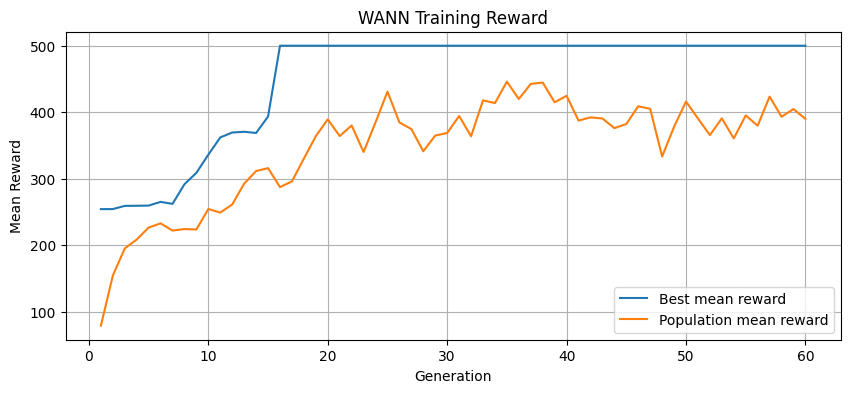

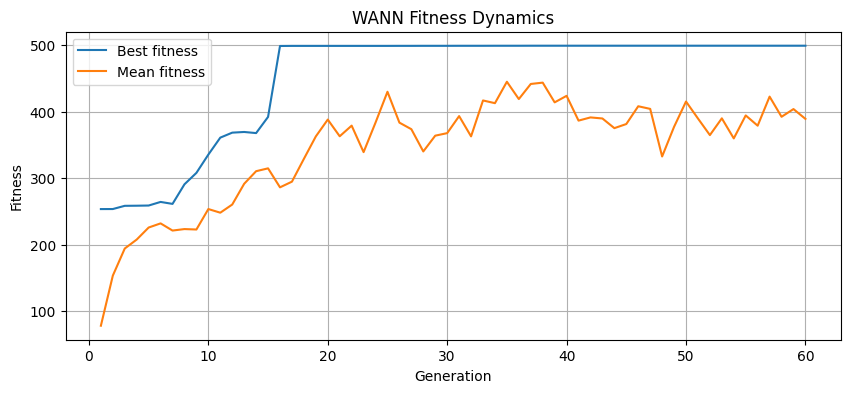

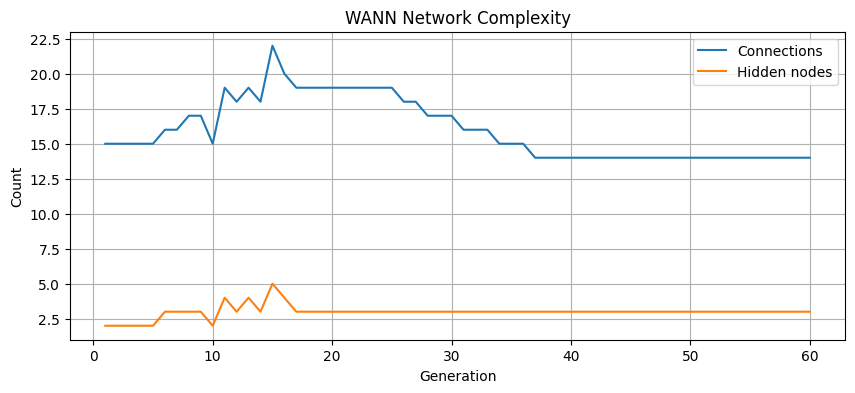

WANN training plots were created.
Final best reward: 500.0
Final population mean reward: 390.0638888888889
Final best connections: 14
Final best hidden nodes: 3


In [6]:
# 画 best reward 曲线
plt.figure(figsize=(10, 4))
plt.plot(wann_log_seed42["generation"], wann_log_seed42["best_mean_reward"], label="Best mean reward")
plt.plot(wann_log_seed42["generation"], wann_log_seed42["population_mean_reward"], label="Population mean reward")
plt.title("WANN Training Reward")
plt.xlabel("Generation")
plt.ylabel("Mean Reward")
plt.grid(True)
plt.legend()
plt.show()

# 画 fitness 曲线
plt.figure(figsize=(10, 4))
plt.plot(wann_log_seed42["generation"], wann_log_seed42["best_fitness"], label="Best fitness")
plt.plot(wann_log_seed42["generation"], wann_log_seed42["mean_fitness"], label="Mean fitness")
plt.title("WANN Fitness Dynamics")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.grid(True)
plt.legend()
plt.show()

# 画复杂度曲线：连接数量和隐藏节点数量
plt.figure(figsize=(10, 4))
plt.plot(wann_log_seed42["generation"], wann_log_seed42["best_connections"], label="Connections")
plt.plot(wann_log_seed42["generation"], wann_log_seed42["best_hidden_nodes"], label="Hidden nodes")
plt.title("WANN Network Complexity")
plt.xlabel("Generation")
plt.ylabel("Count")
plt.grid(True)
plt.legend()
plt.show()

print("WANN training plots were created.")
print("Final best reward:", wann_log_seed42["best_mean_reward"].iloc[-1])
print("Final population mean reward:", wann_log_seed42["population_mean_reward"].iloc[-1])
print("Final best connections:", wann_log_seed42["best_connections"].iloc[-1])
print("Final best hidden nodes:", wann_log_seed42["best_hidden_nodes"].iloc[-1])

In [8]:
print("Start second WANN training with another seed...")

best_wann_seed123, best_wann_result_seed123, wann_log_seed123 = train_wann(
    config=config,
    seed=123,
    allow_activation_mutation=True,
    label="WANN"
)

print("Second WANN training completed.")
print("Best fitness:", best_wann_result_seed123["fitness"])
print("Best mean reward:", best_wann_result_seed123["mean_reward"])
print("Best hidden nodes:", best_wann_result_seed123["hidden_nodes"])
print("Best connections:", best_wann_result_seed123["connections"])
print("Total fitness evaluations:", wann_log_seed123["total_fitness_evaluations"].iloc[-1])

Start second WANN training with another seed...
WANN | Seed 123 | Generation 1: best_reward=254.56, mean_reward=75.14, connections=16, hidden=2
WANN | Seed 123 | Generation 10: best_reward=254.61, mean_reward=208.58, connections=15, hidden=2
WANN | Seed 123 | Generation 20: best_reward=267.44, mean_reward=218.49, connections=13, hidden=2
WANN | Seed 123 | Generation 30: best_reward=433.11, mean_reward=357.97, connections=16, hidden=3
WANN | Seed 123 | Generation 40: best_reward=500.00, mean_reward=347.05, connections=21, hidden=3
WANN | Seed 123 | Generation 50: best_reward=500.00, mean_reward=406.04, connections=18, hidden=3
WANN | Seed 123 | Generation 60: best_reward=500.00, mean_reward=445.77, connections=15, hidden=3
Second WANN training completed.
Best fitness: 498.95
Best mean reward: 500.0
Best hidden nodes: 3
Best connections: 15
Total fitness evaluations: 2400


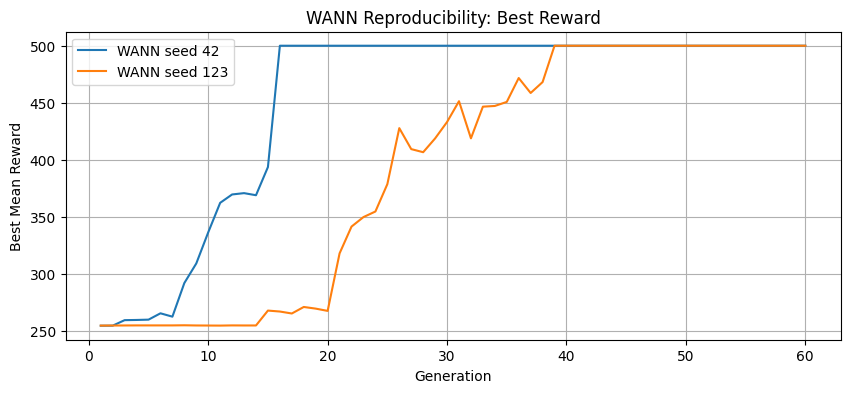

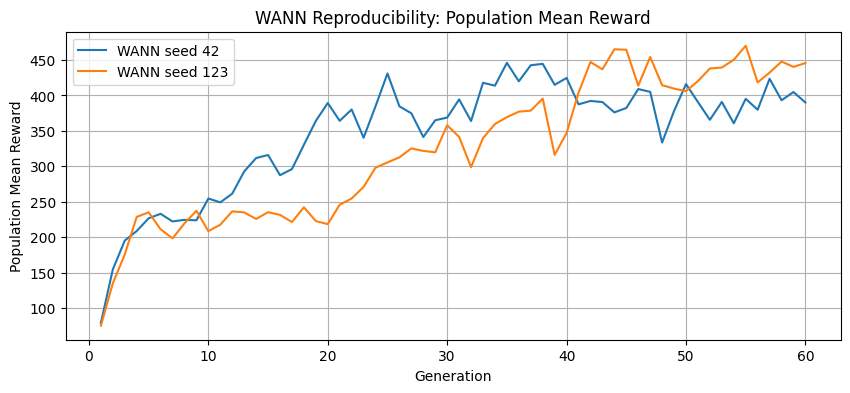

Reproducibility summary:


,Seed,Best Mean Reward,Best Fitness,Hidden Nodes,Connections,Fitness Evaluations
0,42,500.0,499.00,3,14,2400
1,123,500.0,498.95,3,15,2400


In [9]:
plt.figure(figsize=(10, 4))
plt.plot(wann_log_seed42["generation"], wann_log_seed42["best_mean_reward"], label="WANN seed 42")
plt.plot(wann_log_seed123["generation"], wann_log_seed123["best_mean_reward"], label="WANN seed 123")
plt.title("WANN Reproducibility: Best Reward")
plt.xlabel("Generation")
plt.ylabel("Best Mean Reward")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(wann_log_seed42["generation"], wann_log_seed42["population_mean_reward"], label="WANN seed 42")
plt.plot(wann_log_seed123["generation"], wann_log_seed123["population_mean_reward"], label="WANN seed 123")
plt.title("WANN Reproducibility: Population Mean Reward")
plt.xlabel("Generation")
plt.ylabel("Population Mean Reward")
plt.grid(True)
plt.legend()
plt.show()

repro_summary = pd.DataFrame({
    "Seed": [42, 123],
    "Best Mean Reward": [
        best_wann_result["mean_reward"],
        best_wann_result_seed123["mean_reward"]
    ],
    "Best Fitness": [
        best_wann_result["fitness"],
        best_wann_result_seed123["fitness"]
    ],
    "Hidden Nodes": [
        best_wann_result["hidden_nodes"],
        best_wann_result_seed123["hidden_nodes"]
    ],
    "Connections": [
        best_wann_result["connections"],
        best_wann_result_seed123["connections"]
    ],
    "Fitness Evaluations": [
        wann_log_seed42["total_fitness_evaluations"].iloc[-1],
        wann_log_seed123["total_fitness_evaluations"].iloc[-1]
    ]
})

print("Reproducibility summary:")
display(repro_summary)

In [10]:
def random_search_baseline(config, seed=42, label="Random Search"):
    # 固定随机种子
    np.random.seed(seed)
    random.seed(seed)

    logs = []
    best_individual = None
    best_result = None

    total_fitness_evaluations = 0

    for gen in range(config["generations"]):
        population = create_initial_population(config)
        eval_results = []

        for i, individual in enumerate(population):
            result = evaluate_individual(
                individual=individual,
                config=config,
                seed=seed + gen * 1000 + i
            )
            eval_results.append(result)
            total_fitness_evaluations += 1

        fitness_values = [r["fitness"] for r in eval_results]
        mean_rewards = [r["mean_reward"] for r in eval_results]

        best_idx = int(np.argmax(fitness_values))
        current_best = eval_results[best_idx]

        if best_result is None or current_best["fitness"] > best_result["fitness"]:
            best_result = current_best.copy()
            best_individual = population[best_idx].copy()

        logs.append({
            "generation": gen + 1,
            "label": label,
            "seed": seed,
            "best_fitness": current_best["fitness"],
            "mean_fitness": np.mean(fitness_values),
            "best_mean_reward": current_best["mean_reward"],
            "population_mean_reward": np.mean(mean_rewards),
            "best_hidden_nodes": current_best["hidden_nodes"],
            "best_connections": current_best["connections"],
            "best_parameters": current_best["parameters"],
            "total_fitness_evaluations": total_fitness_evaluations
        })

        if (gen + 1) % 10 == 0 or gen == 0:
            print(
                f"{label} | Seed {seed} | Generation {gen + 1}: "
                f"best_reward={current_best['mean_reward']:.2f}, "
                f"mean_reward={np.mean(mean_rewards):.2f}"
            )

    return best_individual, best_result, pd.DataFrame(logs)


print("Start Random Search baseline...")

best_random, best_random_result, random_log = random_search_baseline(
    config=config,
    seed=42,
    label="Random Search"
)

print("Random Search completed.")
print("Best fitness:", best_random_result["fitness"])
print("Best mean reward:", best_random_result["mean_reward"])
print("Best hidden nodes:", best_random_result["hidden_nodes"])
print("Best connections:", best_random_result["connections"])
print("Total fitness evaluations:", random_log["total_fitness_evaluations"].iloc[-1])

Start Random Search baseline...
Random Search | Seed 42 | Generation 1: best_reward=254.44, mean_reward=79.24
Random Search | Seed 42 | Generation 10: best_reward=247.50, mean_reward=54.37
Random Search | Seed 42 | Generation 20: best_reward=254.39, mean_reward=65.76
Random Search | Seed 42 | Generation 30: best_reward=230.56, mean_reward=54.29
Random Search | Seed 42 | Generation 40: best_reward=254.56, mean_reward=70.03
Random Search | Seed 42 | Generation 50: best_reward=254.67, mean_reward=71.30
Random Search | Seed 42 | Generation 60: best_reward=209.56, mean_reward=64.21
Random Search completed.
Best fitness: 258.3833333333333
Best mean reward: 259.3333333333333
Best hidden nodes: 2
Best connections: 15
Total fitness evaluations: 2400


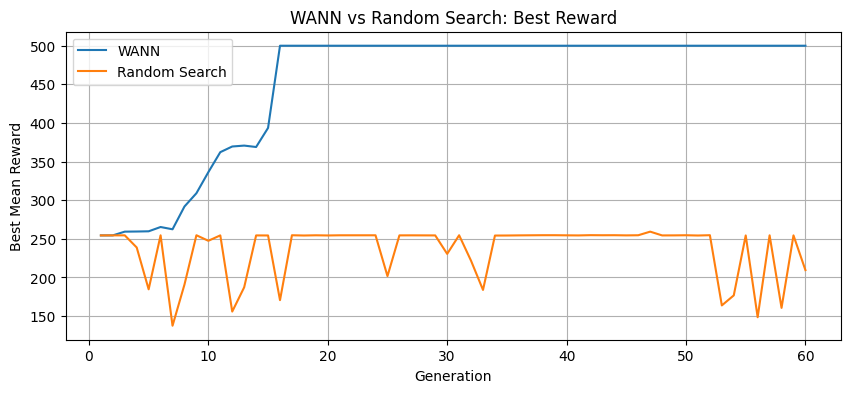

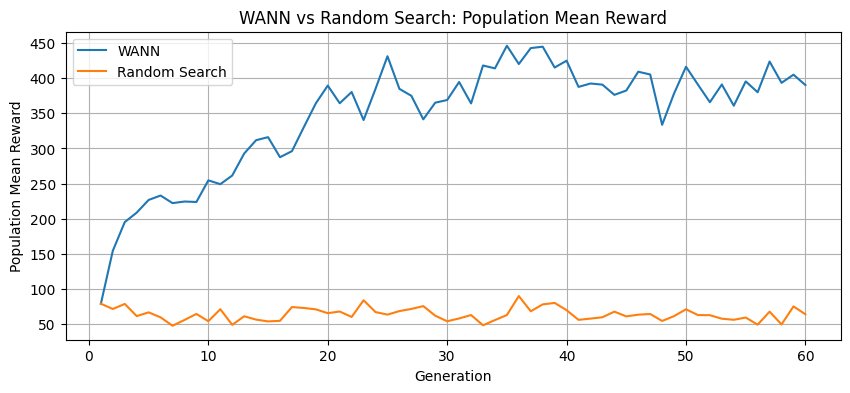

Baseline comparison summary:


,Method,Best Mean Reward,Best Fitness,Hidden Nodes,Connections,Fitness Evaluations
0,WANN,500.000000,499.000000,3,14,2400
1,Random Search,259.333333,258.383333,2,15,2400


In [11]:
plt.figure(figsize=(10, 4))
plt.plot(wann_log_seed42["generation"], wann_log_seed42["best_mean_reward"], label="WANN")
plt.plot(random_log["generation"], random_log["best_mean_reward"], label="Random Search")
plt.title("WANN vs Random Search: Best Reward")
plt.xlabel("Generation")
plt.ylabel("Best Mean Reward")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(wann_log_seed42["generation"], wann_log_seed42["population_mean_reward"], label="WANN")
plt.plot(random_log["generation"], random_log["population_mean_reward"], label="Random Search")
plt.title("WANN vs Random Search: Population Mean Reward")
plt.xlabel("Generation")
plt.ylabel("Population Mean Reward")
plt.grid(True)
plt.legend()
plt.show()

baseline_summary = pd.DataFrame({
    "Method": ["WANN", "Random Search"],
    "Best Mean Reward": [
        best_wann_result["mean_reward"],
        best_random_result["mean_reward"]
    ],
    "Best Fitness": [
        best_wann_result["fitness"],
        best_random_result["fitness"]
    ],
    "Hidden Nodes": [
        best_wann_result["hidden_nodes"],
        best_random_result["hidden_nodes"]
    ],
    "Connections": [
        best_wann_result["connections"],
        best_random_result["connections"]
    ],
    "Fitness Evaluations": [
        wann_log_seed42["total_fitness_evaluations"].iloc[-1],
        random_log["total_fitness_evaluations"].iloc[-1]
    ]
})

print("Baseline comparison summary:")
display(baseline_summary)

In [12]:
print("Start ablation experiment: no activation mutation...")

best_ablation, best_ablation_result, ablation_log = train_wann(
    config=config,
    seed=42,
    allow_activation_mutation=False,
    label="WANN without activation mutation"
)

print("Ablation training completed.")
print("Best fitness:", best_ablation_result["fitness"])
print("Best mean reward:", best_ablation_result["mean_reward"])
print("Best hidden nodes:", best_ablation_result["hidden_nodes"])
print("Best connections:", best_ablation_result["connections"])
print("Total fitness evaluations:", ablation_log["total_fitness_evaluations"].iloc[-1])

Start ablation experiment: no activation mutation...
WANN without activation mutation | Seed 42 | Generation 1: best_reward=254.44, mean_reward=79.24, connections=15, hidden=2
WANN without activation mutation | Seed 42 | Generation 10: best_reward=254.72, mean_reward=218.62, connections=13, hidden=2
WANN without activation mutation | Seed 42 | Generation 20: best_reward=257.28, mean_reward=235.78, connections=15, hidden=3
WANN without activation mutation | Seed 42 | Generation 30: best_reward=267.22, mean_reward=247.09, connections=14, hidden=3
WANN without activation mutation | Seed 42 | Generation 40: best_reward=263.39, mean_reward=227.23, connections=14, hidden=3
WANN without activation mutation | Seed 42 | Generation 50: best_reward=268.11, mean_reward=230.94, connections=23, hidden=6
WANN without activation mutation | Seed 42 | Generation 60: best_reward=274.00, mean_reward=228.53, connections=23, hidden=5
Ablation training completed.
Best fitness: 274.6333333333333
Best mean rew

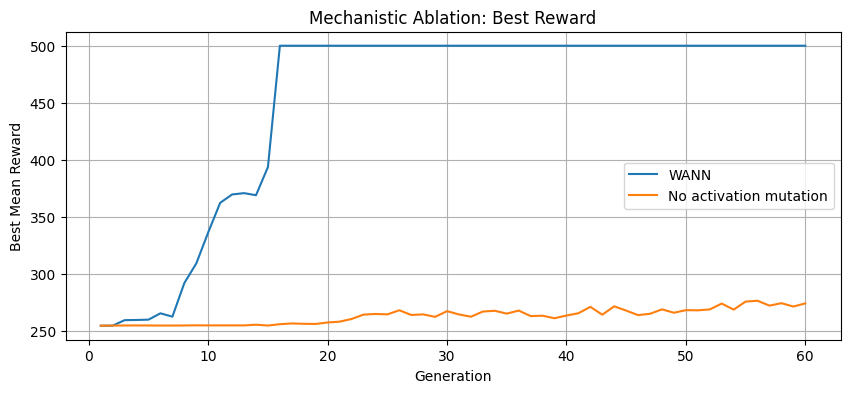

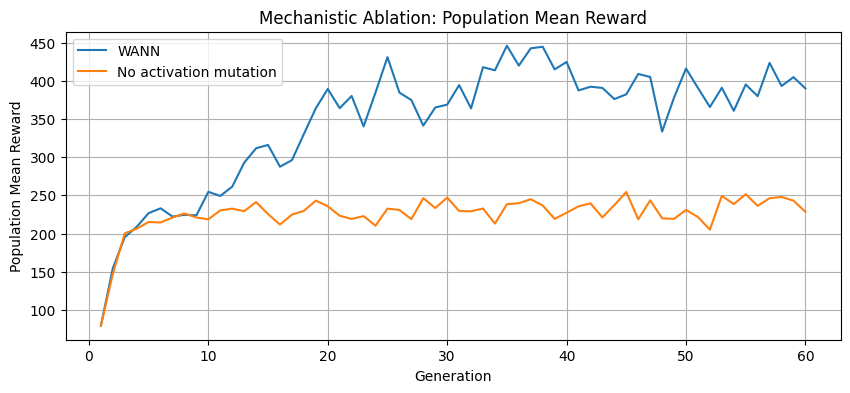

Ablation summary:


,Method,Best Mean Reward,Best Fitness,Hidden Nodes,Connections,Fitness Evaluations
0,WANN,500.000000,499.000000,3,14,2400
1,No activation mutation,276.333333,274.633333,6,22,2400


In [13]:
plt.figure(figsize=(10, 4))
plt.plot(wann_log_seed42["generation"], wann_log_seed42["best_mean_reward"], label="WANN")
plt.plot(ablation_log["generation"], ablation_log["best_mean_reward"], label="No activation mutation")
plt.title("Mechanistic Ablation: Best Reward")
plt.xlabel("Generation")
plt.ylabel("Best Mean Reward")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(wann_log_seed42["generation"], wann_log_seed42["population_mean_reward"], label="WANN")
plt.plot(ablation_log["generation"], ablation_log["population_mean_reward"], label="No activation mutation")
plt.title("Mechanistic Ablation: Population Mean Reward")
plt.xlabel("Generation")
plt.ylabel("Population Mean Reward")
plt.grid(True)
plt.legend()
plt.show()

ablation_summary = pd.DataFrame({
    "Method": ["WANN", "No activation mutation"],
    "Best Mean Reward": [
        best_wann_result["mean_reward"],
        best_ablation_result["mean_reward"]
    ],
    "Best Fitness": [
        best_wann_result["fitness"],
        best_ablation_result["fitness"]
    ],
    "Hidden Nodes": [
        best_wann_result["hidden_nodes"],
        best_ablation_result["hidden_nodes"]
    ],
    "Connections": [
        best_wann_result["connections"],
        best_ablation_result["connections"]
    ],
    "Fitness Evaluations": [
        wann_log_seed42["total_fitness_evaluations"].iloc[-1],
        ablation_log["total_fitness_evaluations"].iloc[-1]
    ]
})

print("Ablation summary:")
display(ablation_summary)

In [14]:
# 创建 population size = 20 的配置
config_pop20 = config.copy()
config_pop20["population_size"] = 20
config_pop20["elite_count"] = 2

print("Start hyperparameter experiment: population size = 20...")

best_pop20, best_pop20_result, pop20_log = train_wann(
    config=config_pop20,
    seed=42,
    allow_activation_mutation=True,
    label="WANN pop20"
)

print("Population size experiment completed.")
print("Best fitness:", best_pop20_result["fitness"])
print("Best mean reward:", best_pop20_result["mean_reward"])
print("Best hidden nodes:", best_pop20_result["hidden_nodes"])
print("Best connections:", best_pop20_result["connections"])
print("Total fitness evaluations:", pop20_log["total_fitness_evaluations"].iloc[-1])

Start hyperparameter experiment: population size = 20...
WANN pop20 | Seed 42 | Generation 1: best_reward=254.44, mean_reward=95.51, connections=15, hidden=2
WANN pop20 | Seed 42 | Generation 10: best_reward=261.83, mean_reward=219.93, connections=18, hidden=3
WANN pop20 | Seed 42 | Generation 20: best_reward=268.17, mean_reward=254.70, connections=20, hidden=3
WANN pop20 | Seed 42 | Generation 30: best_reward=263.33, mean_reward=208.71, connections=18, hidden=3
WANN pop20 | Seed 42 | Generation 40: best_reward=265.67, mean_reward=238.83, connections=17, hidden=3
WANN pop20 | Seed 42 | Generation 50: best_reward=268.17, mean_reward=245.84, connections=19, hidden=3
WANN pop20 | Seed 42 | Generation 60: best_reward=263.83, mean_reward=224.22, connections=19, hidden=3
Population size experiment completed.
Best fitness: 272.57222222222225
Best mean reward: 273.72222222222223
Best hidden nodes: 3
Best connections: 17
Total fitness evaluations: 1200


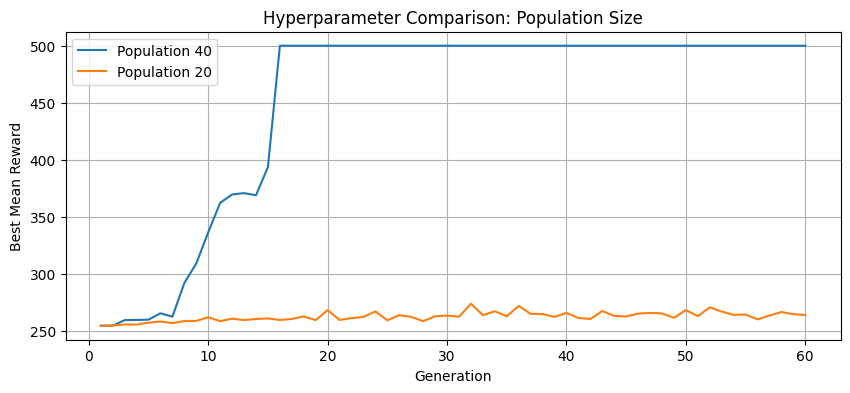

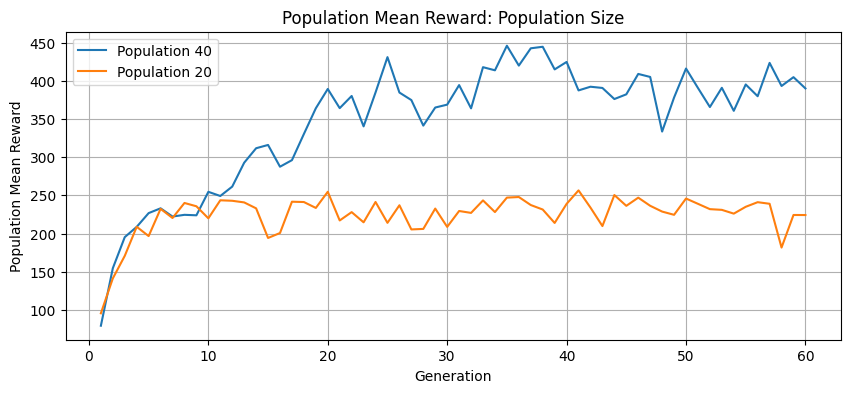

Population size comparison summary:


,Population Size,Best Mean Reward,Best Fitness,Hidden Nodes,Connections,Fitness Evaluations
0,40,500.000000,499.000000,3,14,2400
1,20,273.722222,272.572222,3,17,1200


In [15]:
plt.figure(figsize=(10, 4))
plt.plot(wann_log_seed42["generation"], wann_log_seed42["best_mean_reward"], label="Population 40")
plt.plot(pop20_log["generation"], pop20_log["best_mean_reward"], label="Population 20")
plt.title("Hyperparameter Comparison: Population Size")
plt.xlabel("Generation")
plt.ylabel("Best Mean Reward")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(wann_log_seed42["generation"], wann_log_seed42["population_mean_reward"], label="Population 40")
plt.plot(pop20_log["generation"], pop20_log["population_mean_reward"], label="Population 20")
plt.title("Population Mean Reward: Population Size")
plt.xlabel("Generation")
plt.ylabel("Population Mean Reward")
plt.grid(True)
plt.legend()
plt.show()

pop_size_summary = pd.DataFrame({
    "Population Size": [40, 20],
    "Best Mean Reward": [
        best_wann_result["mean_reward"],
        best_pop20_result["mean_reward"]
    ],
    "Best Fitness": [
        best_wann_result["fitness"],
        best_pop20_result["fitness"]
    ],
    "Hidden Nodes": [
        best_wann_result["hidden_nodes"],
        best_pop20_result["hidden_nodes"]
    ],
    "Connections": [
        best_wann_result["connections"],
        best_pop20_result["connections"]
    ],
    "Fitness Evaluations": [
        wann_log_seed42["total_fitness_evaluations"].iloc[-1],
        pop20_log["total_fitness_evaluations"].iloc[-1]
    ]
})

print("Population size comparison summary:")
display(pop_size_summary)

In [16]:
# 创建高变异率配置
config_high_mut = config.copy()
config_high_mut["add_node_prob"] = 0.20
config_high_mut["add_connection_prob"] = 0.45
config_high_mut["activation_mutation_prob"] = 0.35

print("Start hyperparameter experiment: high mutation rate...")

best_high_mut, best_high_mut_result, high_mut_log = train_wann(
    config=config_high_mut,
    seed=42,
    allow_activation_mutation=True,
    label="WANN high mutation"
)

print("High mutation experiment completed.")
print("Best fitness:", best_high_mut_result["fitness"])
print("Best mean reward:", best_high_mut_result["mean_reward"])
print("Best hidden nodes:", best_high_mut_result["hidden_nodes"])
print("Best connections:", best_high_mut_result["connections"])
print("Total fitness evaluations:", high_mut_log["total_fitness_evaluations"].iloc[-1])

Start hyperparameter experiment: high mutation rate...
WANN high mutation | Seed 42 | Generation 1: best_reward=160.89, mean_reward=53.71, connections=16, hidden=2
WANN high mutation | Seed 42 | Generation 10: best_reward=254.78, mean_reward=180.20, connections=18, hidden=2
WANN high mutation | Seed 42 | Generation 20: best_reward=336.44, mean_reward=265.14, connections=15, hidden=2
WANN high mutation | Seed 42 | Generation 30: best_reward=500.00, mean_reward=404.92, connections=18, hidden=3
WANN high mutation | Seed 42 | Generation 40: best_reward=500.00, mean_reward=416.81, connections=17, hidden=3
WANN high mutation | Seed 42 | Generation 50: best_reward=500.00, mean_reward=422.80, connections=15, hidden=3
WANN high mutation | Seed 42 | Generation 60: best_reward=500.00, mean_reward=420.55, connections=15, hidden=3
High mutation experiment completed.
Best fitness: 498.95
Best mean reward: 500.0
Best hidden nodes: 3
Best connections: 15
Total fitness evaluations: 2400


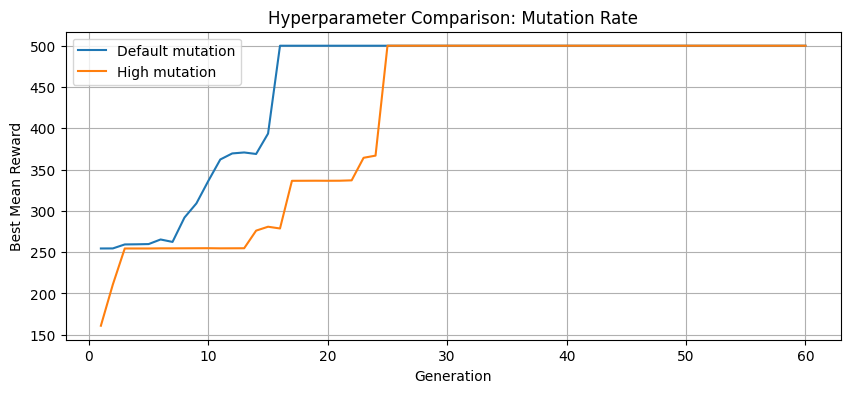

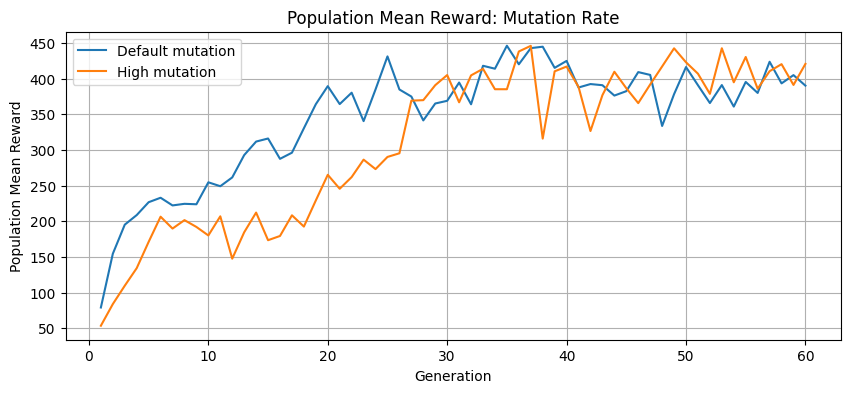

Mutation rate comparison summary:


,Mutation Setting,Add Node Prob,Add Connection Prob,Activation Mutation Prob,Best Mean Reward,Best Fitness,Hidden Nodes,Connections,Fitness Evaluations
0,Default,0.1,0.25,0.20,500.0,499.00,3,14,2400
1,High,0.2,0.45,0.35,500.0,498.95,3,15,2400


In [17]:
plt.figure(figsize=(10, 4))
plt.plot(wann_log_seed42["generation"], wann_log_seed42["best_mean_reward"], label="Default mutation")
plt.plot(high_mut_log["generation"], high_mut_log["best_mean_reward"], label="High mutation")
plt.title("Hyperparameter Comparison: Mutation Rate")
plt.xlabel("Generation")
plt.ylabel("Best Mean Reward")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(wann_log_seed42["generation"], wann_log_seed42["population_mean_reward"], label="Default mutation")
plt.plot(high_mut_log["generation"], high_mut_log["population_mean_reward"], label="High mutation")
plt.title("Population Mean Reward: Mutation Rate")
plt.xlabel("Generation")
plt.ylabel("Population Mean Reward")
plt.grid(True)
plt.legend()
plt.show()

mutation_summary = pd.DataFrame({
    "Mutation Setting": ["Default", "High"],
    "Add Node Prob": [
        config["add_node_prob"],
        config_high_mut["add_node_prob"]
    ],
    "Add Connection Prob": [
        config["add_connection_prob"],
        config_high_mut["add_connection_prob"]
    ],
    "Activation Mutation Prob": [
        config["activation_mutation_prob"],
        config_high_mut["activation_mutation_prob"]
    ],
    "Best Mean Reward": [
        best_wann_result["mean_reward"],
        best_high_mut_result["mean_reward"]
    ],
    "Best Fitness": [
        best_wann_result["fitness"],
        best_high_mut_result["fitness"]
    ],
    "Hidden Nodes": [
        best_wann_result["hidden_nodes"],
        best_high_mut_result["hidden_nodes"]
    ],
    "Connections": [
        best_wann_result["connections"],
        best_high_mut_result["connections"]
    ],
    "Fitness Evaluations": [
        wann_log_seed42["total_fitness_evaluations"].iloc[-1],
        high_mut_log["total_fitness_evaluations"].iloc[-1]
    ]
})

print("Mutation rate comparison summary:")
display(mutation_summary)

In [18]:
def test_individual(individual, config, seed=42, test_episodes=100, noise_std=0.0, action_noise_prob=0.0):
    rewards = []

    # 测试时选择表现最好的 shared weight
    candidate_weights = config["shared_weights"]
    weight_scores = []

    for weight in candidate_weights:
        temp_rewards = []

        for ep in range(10):
            reward = evaluate_episode(
                individual=individual,
                env_name=config["env_name"],
                shared_weight=weight,
                seed=seed + ep,
                noise_std=0.0,
                action_noise_prob=0.0
            )
            temp_rewards.append(reward)

        weight_scores.append(np.mean(temp_rewards))

    best_weight = candidate_weights[int(np.argmax(weight_scores))]

    # 用最佳 shared weight 做正式测试
    for ep in range(test_episodes):
        reward = evaluate_episode(
            individual=individual,
            env_name=config["env_name"],
            shared_weight=best_weight,
            seed=seed + 1000 + ep,
            noise_std=noise_std,
            action_noise_prob=action_noise_prob
        )
        rewards.append(reward)

    return {
        "mean_reward": np.mean(rewards),
        "std_reward": np.std(rewards),
        "min_reward": np.min(rewards),
        "max_reward": np.max(rewards),
        "best_weight": best_weight,
        "rewards": rewards
    }


# 基础环境测试
base_test = test_individual(
    individual=best_wann,
    config=config,
    seed=42,
    test_episodes=config["test_episodes"],
    noise_std=0.0
)

# 修改环境：observation noise
noise_test_005 = test_individual(
    individual=best_wann,
    config=config,
    seed=42,
    test_episodes=config["test_episodes"],
    noise_std=0.05
)

noise_test_010 = test_individual(
    individual=best_wann,
    config=config,
    seed=42,
    test_episodes=config["test_episodes"],
    noise_std=0.10
)

robustness_summary = pd.DataFrame({
    "Test Condition": [
        "Base environment",
        "Observation noise std=0.05",
        "Observation noise std=0.10"
    ],
    "Mean Reward": [
        base_test["mean_reward"],
        noise_test_005["mean_reward"],
        noise_test_010["mean_reward"]
    ],
    "Std Reward": [
        base_test["std_reward"],
        noise_test_005["std_reward"],
        noise_test_010["std_reward"]
    ],
    "Min Reward": [
        base_test["min_reward"],
        noise_test_005["min_reward"],
        noise_test_010["min_reward"]
    ],
    "Max Reward": [
        base_test["max_reward"],
        noise_test_005["max_reward"],
        noise_test_010["max_reward"]
    ],
    "Best Shared Weight": [
        base_test["best_weight"],
        noise_test_005["best_weight"],
        noise_test_010["best_weight"]
    ]
})

print("Robustness test completed.")
display(robustness_summary)

Robustness test completed.


,Test Condition,Mean Reward,Std Reward,Min Reward,Max Reward,Best Shared Weight
0,Base environment,500.00,0.000000,500.0,500.0,-2.0
1,Observation noise std=0.05,498.09,19.004260,309.0,500.0,-2.0
2,Observation noise std=0.10,187.41,107.438363,54.0,500.0,-2.0


/tmp/ipykernel_879/2493675057.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


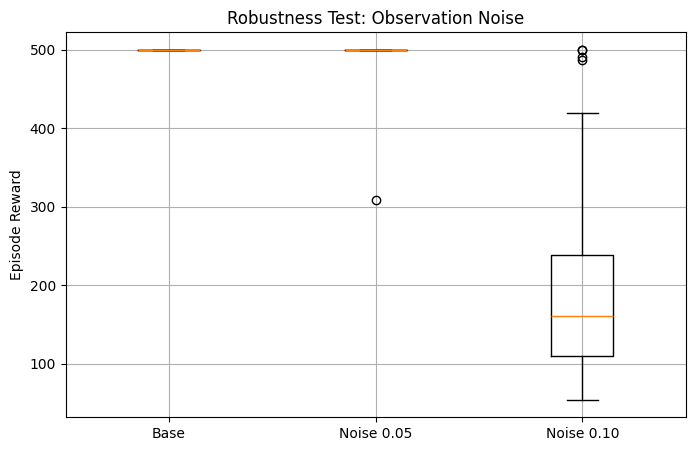

Robustness plot was created.
Base mean reward: 500.0
Noise 0.05 mean reward: 498.09
Noise 0.10 mean reward: 187.41


In [19]:
plt.figure(figsize=(8, 5))
plt.boxplot(
    [
        base_test["rewards"],
        noise_test_005["rewards"],
        noise_test_010["rewards"]
    ],
    labels=[
        "Base",
        "Noise 0.05",
        "Noise 0.10"
    ]
)
plt.title("Robustness Test: Observation Noise")
plt.ylabel("Episode Reward")
plt.grid(True)
plt.show()

print("Robustness plot was created.")
print("Base mean reward:", base_test["mean_reward"])
print("Noise 0.05 mean reward:", noise_test_005["mean_reward"])
print("Noise 0.10 mean reward:", noise_test_010["mean_reward"])

In [22]:
# 把 numpy 类型转换成普通 Python 类型，方便保存为 JSON
def convert_to_json_serializable(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, tuple):
        return [convert_to_json_serializable(x) for x in obj]
    elif isinstance(obj, list):
        return [convert_to_json_serializable(x) for x in obj]
    elif isinstance(obj, dict):
        return {
            str(convert_to_json_serializable(k)): convert_to_json_serializable(v)
            for k, v in obj.items()
        }
    else:
        return obj


def individual_to_dict(individual, best_shared_weight=None):
    # 把 WANN 个体转换成可以保存的字典
    data = {
        "input_dim": individual.input_dim,
        "output_dim": individual.output_dim,
        "max_hidden_nodes": individual.max_hidden_nodes,
        "input_nodes": individual.input_nodes,
        "output_nodes": individual.output_nodes,
        "hidden_nodes": individual.hidden_nodes,
        "next_node_id": individual.next_node_id,
        "connections": individual.connections,
        "activations": individual.activations,
        "best_shared_weight": best_shared_weight
    }

    return convert_to_json_serializable(data)


def dict_to_individual(data):
    # 从字典恢复 WANN 个体
    individual = WANNIndividual(
        input_dim=int(data["input_dim"]),
        output_dim=int(data["output_dim"]),
        max_hidden_nodes=int(data["max_hidden_nodes"])
    )

    individual.input_nodes = [int(x) for x in data["input_nodes"]]
    individual.output_nodes = [int(x) for x in data["output_nodes"]]
    individual.hidden_nodes = [int(x) for x in data["hidden_nodes"]]
    individual.next_node_id = int(data["next_node_id"])

    # JSON 会把 tuple 保存成 list，所以这里转回 tuple
    individual.connections = [tuple(map(int, conn)) for conn in data["connections"]]

    # JSON 会把字典 key 转成字符串，所以这里转回 int
    individual.activations = {
        int(node): act for node, act in data["activations"].items()
    }

    return individual


# 选择测试阶段表现最好的 shared weight
best_shared_weight = float(base_test["best_weight"])

# 转换最优 WANN 个体
best_wann_data = individual_to_dict(
    best_wann,
    best_shared_weight=best_shared_weight
)

# 保存网络结构
model_file = "best_wann_structure.json"

with open(model_file, "w", encoding="utf-8") as f:
    json.dump(best_wann_data, f, indent=4, ensure_ascii=False)

# 保存实验配置
config_file = "wann_config.json"

clean_config = convert_to_json_serializable(config)

with open(config_file, "w", encoding="utf-8") as f:
    json.dump(clean_config, f, indent=4, ensure_ascii=False)

print("Best WANN structure saved.")
print("Model file:", model_file)
print("Config file:", config_file)
print("Best shared weight:", best_shared_weight)
print("Saved hidden nodes:", best_wann_data["hidden_nodes"])
print("Saved connections:", len(best_wann_data["connections"]))

Best WANN structure saved.
Model file: best_wann_structure.json
Config file: wann_config.json
Best shared weight: -2.0
Saved hidden nodes: [6, 7, 8]
Saved connections: 14


In [23]:
# 从文件加载最优网络结构
with open("best_wann_structure.json", "r", encoding="utf-8") as f:
    loaded_data = json.load(f)

loaded_wann = dict_to_individual(loaded_data)
loaded_weight = loaded_data["best_shared_weight"]

# 测试加载后的个体
loaded_test = test_individual(
    individual=loaded_wann,
    config=config,
    seed=42,
    test_episodes=100,
    noise_std=0.0
)

print("Loaded WANN tested.")
print("Loaded best shared weight:", loaded_weight)
print("Loaded mean reward:", loaded_test["mean_reward"])
print("Loaded std reward:", loaded_test["std_reward"])
print("Loaded hidden nodes:", loaded_wann.complexity()["hidden_nodes"])
print("Loaded connections:", loaded_wann.complexity()["connections"])

Loaded WANN tested.
Loaded best shared weight: -2.0
Loaded mean reward: 500.0
Loaded std reward: 0.0
Loaded hidden nodes: 3
Loaded connections: 14


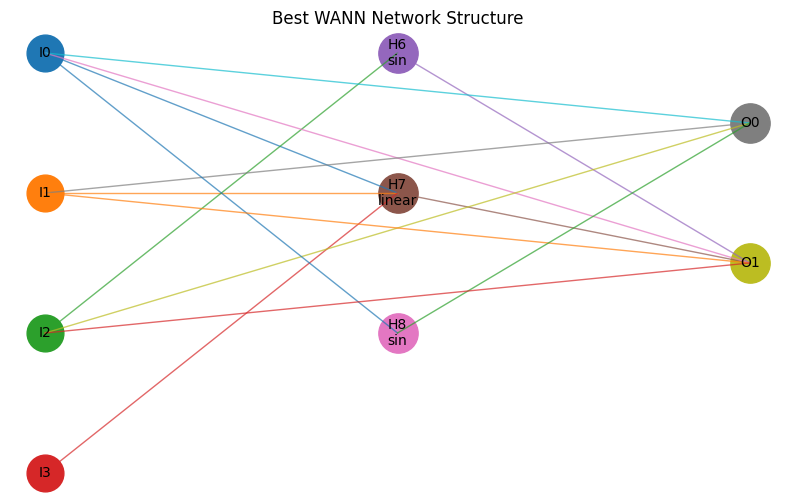

Best WANN network structure was plotted.
Hidden nodes: [np.int64(6), np.int64(7), np.int64(8)]
Connections: [(0, np.int64(7)), (1, np.int64(7)), (2, np.int64(6)), (3, np.int64(7)), (np.int64(6), 5), (np.int64(7), 5), (0, 5), (1, 4), (2, 4), (0, 4), (0, np.int64(8)), (1, 5), (np.int64(8), 4), (2, 5)]
Activations: {4: 'linear', 5: 'linear', np.int64(6): 'sin', np.int64(7): 'linear', np.int64(8): 'sin'}
Complexity: {'hidden_nodes': 3, 'connections': 14, 'parameters': 14}


In [24]:
def plot_wann_structure(individual, title="Best WANN Network Structure"):
    # 设置节点位置
    positions = {}

    # 输入节点放左侧
    for i, node in enumerate(individual.input_nodes):
        positions[node] = (0, -i)

    # 隐藏节点放中间
    for i, node in enumerate(individual.hidden_nodes):
        positions[node] = (1.5, -i)

    # 输出节点放右侧
    for i, node in enumerate(individual.output_nodes):
        positions[node] = (3.0, -i - 0.5)

    plt.figure(figsize=(10, 6))

    # 画连接
    for src, dst in individual.connections:
        if src in positions and dst in positions:
            x1, y1 = positions[src]
            x2, y2 = positions[dst]
            plt.plot([x1, x2], [y1, y2], linewidth=1, alpha=0.7)

    # 画输入节点
    for node in individual.input_nodes:
        x, y = positions[node]
        plt.scatter(x, y, s=700)
        plt.text(x, y, f"I{node}", ha="center", va="center")

    # 画隐藏节点
    for node in individual.hidden_nodes:
        x, y = positions[node]
        act = individual.activations.get(node, "none")
        plt.scatter(x, y, s=800)
        plt.text(x, y, f"H{node}\n{act}", ha="center", va="center")

    # 画输出节点
    for i, node in enumerate(individual.output_nodes):
        x, y = positions[node]
        plt.scatter(x, y, s=800)
        plt.text(x, y, f"O{i}", ha="center", va="center")

    plt.title(title)
    plt.axis("off")
    plt.show()


plot_wann_structure(
    best_wann,
    title="Best WANN Network Structure"
)

print("Best WANN network structure was plotted.")
print("Hidden nodes:", best_wann.hidden_nodes)
print("Connections:", best_wann.connections)
print("Activations:", best_wann.activations)
print("Complexity:", best_wann.complexity())

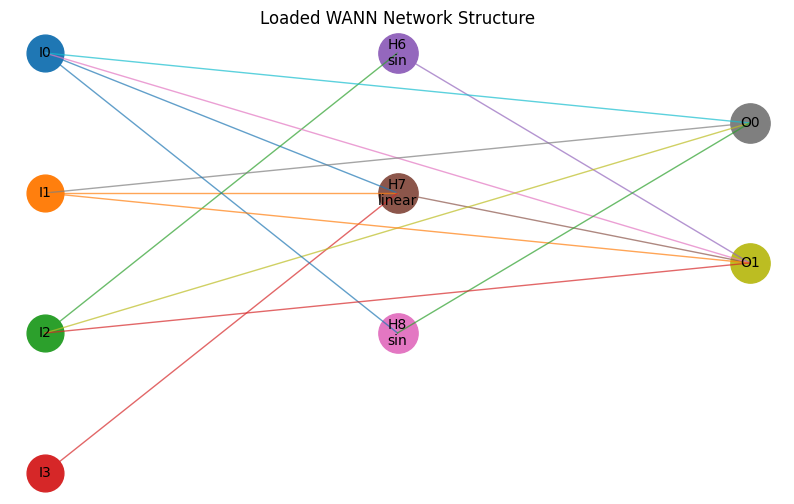

Loaded WANN network structure was plotted.
Loaded complexity: {'hidden_nodes': 3, 'connections': 14, 'parameters': 14}


In [25]:
plot_wann_structure(
    loaded_wann,
    title="Loaded WANN Network Structure"
)

print("Loaded WANN network structure was plotted.")
print("Loaded complexity:", loaded_wann.complexity())

In [26]:
failure_summary = pd.DataFrame({
    "Failure Mode": [
        "Random Search",
        "No activation mutation",
        "Small population size"
    ],
    "Reason": [
        "No evolutionary selection and no inheritance of good structures",
        "Activation functions cannot evolve, so the search space is limited",
        "Population diversity is too low for stable structural search"
    ],
    "Best Mean Reward": [
        best_random_result["mean_reward"],
        best_ablation_result["mean_reward"],
        best_pop20_result["mean_reward"]
    ],
    "Best Fitness": [
        best_random_result["fitness"],
        best_ablation_result["fitness"],
        best_pop20_result["fitness"]
    ],
    "Hidden Nodes": [
        best_random_result["hidden_nodes"],
        best_ablation_result["hidden_nodes"],
        best_pop20_result["hidden_nodes"]
    ],
    "Connections": [
        best_random_result["connections"],
        best_ablation_result["connections"],
        best_pop20_result["connections"]
    ],
    "Compared with WANN": [
        best_random_result["mean_reward"] - best_wann_result["mean_reward"],
        best_ablation_result["mean_reward"] - best_wann_result["mean_reward"],
        best_pop20_result["mean_reward"] - best_wann_result["mean_reward"]
    ]
})

print("Failure mode summary:")
display(failure_summary)

Failure mode summary:


,Failure Mode,Reason,Best Mean Reward,Best Fitness,Hidden Nodes,Connections,Compared with WANN
0,Random Search,No evolutionary selection and no inheritance o...,259.333333,258.383333,2,15,-240.666667
1,No activation mutation,"Activation functions cannot evolve, so the sea...",276.333333,274.633333,6,22,-223.666667
2,Small population size,Population diversity is too low for stable str...,273.722222,272.572222,3,17,-226.277778


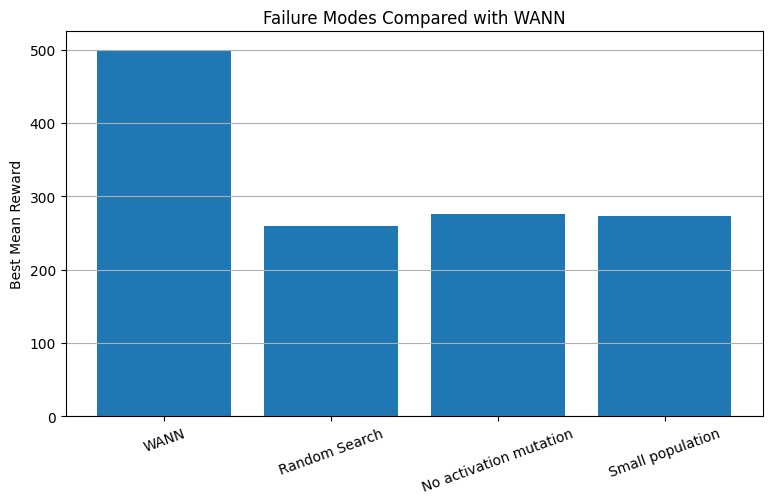

Failure mode plot was created.
WANN reward: 500.0
Random Search reward: 259.3333333333333
No activation mutation reward: 276.3333333333333
Small population reward: 273.72222222222223


In [27]:
plt.figure(figsize=(9, 5))

methods = [
    "WANN",
    "Random Search",
    "No activation mutation",
    "Small population"
]

rewards = [
    best_wann_result["mean_reward"],
    best_random_result["mean_reward"],
    best_ablation_result["mean_reward"],
    best_pop20_result["mean_reward"]
]

plt.bar(methods, rewards)
plt.title("Failure Modes Compared with WANN")
plt.ylabel("Best Mean Reward")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

print("Failure mode plot was created.")
print("WANN reward:", best_wann_result["mean_reward"])
print("Random Search reward:", best_random_result["mean_reward"])
print("No activation mutation reward:", best_ablation_result["mean_reward"])
print("Small population reward:", best_pop20_result["mean_reward"])

In [28]:
final_summary = pd.DataFrame({
    "Experiment": [
        "Main WANN seed 42",
        "Main WANN seed 123",
        "Random Search baseline",
        "Ablation: no activation mutation",
        "Hyperparameter: population size 20",
        "Hyperparameter: high mutation",
        "Robustness: base environment",
        "Robustness: observation noise 0.05",
        "Robustness: observation noise 0.10"
    ],
    "Best / Mean Reward": [
        best_wann_result["mean_reward"],
        best_wann_result_seed123["mean_reward"],
        best_random_result["mean_reward"],
        best_ablation_result["mean_reward"],
        best_pop20_result["mean_reward"],
        best_high_mut_result["mean_reward"],
        base_test["mean_reward"],
        noise_test_005["mean_reward"],
        noise_test_010["mean_reward"]
    ],
    "Fitness": [
        best_wann_result["fitness"],
        best_wann_result_seed123["fitness"],
        best_random_result["fitness"],
        best_ablation_result["fitness"],
        best_pop20_result["fitness"],
        best_high_mut_result["fitness"],
        np.nan,
        np.nan,
        np.nan
    ],
    "Hidden Nodes": [
        best_wann_result["hidden_nodes"],
        best_wann_result_seed123["hidden_nodes"],
        best_random_result["hidden_nodes"],
        best_ablation_result["hidden_nodes"],
        best_pop20_result["hidden_nodes"],
        best_high_mut_result["hidden_nodes"],
        best_wann_result["hidden_nodes"],
        best_wann_result["hidden_nodes"],
        best_wann_result["hidden_nodes"]
    ],
    "Connections": [
        best_wann_result["connections"],
        best_wann_result_seed123["connections"],
        best_random_result["connections"],
        best_ablation_result["connections"],
        best_pop20_result["connections"],
        best_high_mut_result["connections"],
        best_wann_result["connections"],
        best_wann_result["connections"],
        best_wann_result["connections"]
    ],
    "Fitness Evaluations": [
        wann_log_seed42["total_fitness_evaluations"].iloc[-1],
        wann_log_seed123["total_fitness_evaluations"].iloc[-1],
        random_log["total_fitness_evaluations"].iloc[-1],
        ablation_log["total_fitness_evaluations"].iloc[-1],
        pop20_log["total_fitness_evaluations"].iloc[-1],
        high_mut_log["total_fitness_evaluations"].iloc[-1],
        np.nan,
        np.nan,
        np.nan
    ]
})

print("Final summary:")
display(final_summary)

Final summary:


,Experiment,Best / Mean Reward,Fitness,Hidden Nodes,Connections,Fitness Evaluations
0,Main WANN seed 42,500.000000,499.000000,3,14,2400.0
1,Main WANN seed 123,500.000000,498.950000,3,15,2400.0
2,Random Search baseline,259.333333,258.383333,2,15,2400.0
3,Ablation: no activation mutation,276.333333,274.633333,6,22,2400.0
4,Hyperparameter: population size 20,273.722222,272.572222,3,17,1200.0
5,Hyperparameter: high mutation,500.000000,498.950000,3,15,2400.0
6,Robustness: base environment,500.000000,NaN,3,14,NaN
7,Robustness: observation noise 0.05,498.090000,NaN,3,14,NaN
8,Robustness: observation noise 0.10,187.410000,NaN,3,14,NaN


In [29]:
result_file = "wann_experiment_results.xlsx"

with pd.ExcelWriter(result_file) as writer:
    final_summary.to_excel(writer, sheet_name="Final Summary", index=False)
    repro_summary.to_excel(writer, sheet_name="Reproducibility", index=False)
    baseline_summary.to_excel(writer, sheet_name="Baseline", index=False)
    ablation_summary.to_excel(writer, sheet_name="Ablation", index=False)
    pop_size_summary.to_excel(writer, sheet_name="Population Size", index=False)
    mutation_summary.to_excel(writer, sheet_name="Mutation Rate", index=False)
    robustness_summary.to_excel(writer, sheet_name="Robustness", index=False)
    failure_summary.to_excel(writer, sheet_name="Failure Modes", index=False)

print("Excel results saved:", result_file)

Excel results saved: wann_experiment_results.xlsx


In [30]:
# 保存每个实验的训练日志
wann_log_seed42.to_csv("wann_log_seed42.csv", index=False)
wann_log_seed123.to_csv("wann_log_seed123.csv", index=False)
random_log.to_csv("random_search_log.csv", index=False)
ablation_log.to_csv("ablation_log.csv", index=False)
pop20_log.to_csv("pop20_log.csv", index=False)
high_mut_log.to_csv("high_mut_log.csv", index=False)

print("Training logs were saved as CSV files.")

Training logs were saved as CSV files.


In [31]:
from google.colab import files

files.download("wann_experiment_results.xlsx")
files.download("best_wann_structure.json")
files.download("wann_config.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>